In [1]:
# CARGA DE DATOS #

import pandas as pd

# Ruta al archivo de Excel
archivo_excel = '../Escritorio/ProyectoICA/IIYNT-REQ-BD-001.xlsx' #../

# Número de la fila desde la cual querés empezar (0-indexado)
fila_inicio = 3

# Leer el archivo Excel
init_df = pd.read_excel(archivo_excel)

# Mostrar las primeras filas del DataFrame para confirmar que se leyó bien
init_df.head()



,Buscador por código de muestra,Rótulo de la muestra,Fecha (DD/MM/AAAA),Horario (24 hrs XX:XX),Ubicación,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),...,Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Clasificación según dureza,Cloruros\n(mg Cl-/L),DQO,DBO5,Arsénico total,Unnamed: 21,Unnamed: 22
0,260623ASA,A,2023-06-26 00:00:00,15:00:00,Arroyo Salguero,18.2,0.77,15.2,8.3,990,...,NaN,2.68,212,SEMIDURA,64,NaN,NaN,#REF!,NaN,NaN
1,Código de la muestra\n(fecha-ubicación-número),Rótulo de la muestra,Fecha (DD/MM/AAAA),Horario (24 hrs XX:XX),Ubicación,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),...,Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Clasificación según dureza,Cloruros\n(mg Cl-/L),DQO,DBO5,Arsénico total,NaN,NaN
2,030523ATA,A,2023-05-03 00:00:00,12:30:00,Arroyo_Las Torres,16,0.929,18.5,8.2,1240,...,NaN,NaN,NaN,NaN,NaN,125,NaN,NaN,NaN,NaN
3,090523PBA,A,2023-05-09 00:00:00,14:15:00,Puente Bilbao,17,0.47,19,8.3,1630,...,NaN,NaN,147,BLANDA,156,NaN,NaN,NaN,NaN,Características del muestreo
4,140623PBA,A,2023-06-14 00:00:00,14:30:00,Puente Bilbao,11.9,0.47,13,8.1,1000,...,NaN,41.2,94,BLANDA,78,NaN,NaN,NaN,NaN,Datos meteorológicos (Servicio Meteorológico N...


In [2]:
# TRANSFORMACIÓN DE DATOS #

desired_columns = [
    'Temperatura Ambiental (°C)', 
    'Humedad',
    'Temperatura de la muestra (°C)', 
    'pH', 
    'CE\n(µS/cm)', 
    #'STD\n(mg/L)',
    'STS\n(mL sed/L)', 
    'OD\n(mg/L)', 
    'Nivel (cm)', 
    'Turbidez (NTU)',
    'Dureza\n(mg CaCO3/L)',
    'Cloruros\n(mg Cl-/L)'
]
df = init_df.iloc[2:102][desired_columns]
df

,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
2,16,0.929,18.5,8.2,1240,NaN,5.37,NaN,NaN,NaN,NaN
3,17,0.47,19,8.3,1630,1.8,4.3,NaN,NaN,147,156
4,11.9,0.47,13,8.1,1000,18,5.3,NaN,41.2,94,78
5,11.9,0.47,13,8.2,1000,18,4.67,NaN,38.9,86,82
6,11.9,0.47,13,8.3,1350,0.1,7.01,NaN,30.7,200,117
...,...,...,...,...,...,...,...,...,...,...,...
97,15.2,0.52,17.6,8.1,750,70,3.8,50,124,135,59
98,15.2,0.52,17.8,7.9,290,1.8,4.82,25,41.3,94,15
99,15.2,0.52,17.9,7.9,200,1.8,5.47,25,41.3,94,15
100,15.2,0.52,18.3,8,990,48,1.92,55,87.2,146,77


In [3]:
#ver los que tienen valores nulos o no asignados

#df.isnull().sum()
df.isna().sum()


Temperatura Ambiental (°C)         0
Humedad                            0
Temperatura de la muestra (°C)     0
pH                                 0
CE\n(µS/cm)                        0
STS\n(mL sed/L)                    3
OD\n(mg/L)                         0
Nivel (cm)                        40
Turbidez (NTU)                     2
Dureza\n(mg CaCO3/L)               1
Cloruros\n(mg Cl-/L)               3
dtype: int64

In [4]:
#Eliminar las filas que tienen valores nulos o no asignados
#df.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true

#Si asigno a nueva variable no hace falta inplace=true pero no modifica el Dataframe original
#df_sin_nulos=df.dropna()

#Como opcion puedo llenar los valores nulos con datos adecuados: 
#fillna(method='bfill') (llenar con el valor siguiente de la columna)
#fillna(method='ffill') (llenar con el valor anterior de la columna)
#fillna(0) (llenar con ceros) 

mediaNivel=df['Nivel (cm)'].mean()
df['Nivel (cm)']=df['Nivel (cm)'].fillna(mediaNivel)

mediaSTS=df['STS\n(mL sed/L)'].mean()
df['STS\n(mL sed/L)']=df['STS\n(mL sed/L)'].fillna(mediaSTS)

mediaTurbidez=df['Turbidez (NTU)'].mean()
df['Turbidez (NTU)']=df['Turbidez (NTU)'].fillna(mediaTurbidez)

mediaDureza=df['Dureza\n(mg CaCO3/L)'].mean()
df['Dureza\n(mg CaCO3/L)']=df['Dureza\n(mg CaCO3/L)'].fillna(mediaDureza)

mediaCloruros=df['Cloruros\n(mg Cl-/L)'].mean()
df['Cloruros\n(mg Cl-/L)']=df['Cloruros\n(mg Cl-/L)'].fillna(mediaCloruros)

df_sin_nulos=df
df_sin_nulos.isna().sum()

#Para eliminar columnas con valores nulos uso:
#df_sin_columnas_con_nulos=df.dropna(axis=1)



Temperatura Ambiental (°C)        0
Humedad                           0
Temperatura de la muestra (°C)    0
pH                                0
CE\n(µS/cm)                       0
STS\n(mL sed/L)                   0
OD\n(mg/L)                        0
Nivel (cm)                        0
Turbidez (NTU)                    0
Dureza\n(mg CaCO3/L)              0
Cloruros\n(mg Cl-/L)              0
dtype: int64

In [5]:
# PROCESO DE SIMULACIÓN #

import pandas as pd
import numpy as np

# Leé el CSV original para no modificar df_sin_nulos por las dudas
df_original = df_sin_nulos

# Creá un DataFrame vacío para guardar los resultados
df_simulado = pd.DataFrame()

# Número de simulaciones que querés hacer
num_simulaciones = 100000 #Si quiero tener en cuenta las relaciones entre las variables planteando escenarios:


for columna in df_original.columns:
    # Calculá la media y la desviación estándar de cada columna
    media = df_original[columna].mean()
    std = df_original[columna].std()

    # Generá datos aleatorios siguiendo una distribución normal
    datos_simulados = np.random.normal(media, std, num_simulaciones)

    # Añadí estos datos al DataFrame de resultados
    df_simulado[columna] = datos_simulados
    


""" for i, valor in enumerate(archivo_excel['Turbidez (NTU)']): #esto si fuera un excell pero ya esta como dataframe
    if valor<val_min_STS:val_max_turbidez
       archivo_excel.at[i,'Turbidez (NTU)']=val_min_STS
    if valor>val_max_STS:
       archivo_excel.at[i,'Turbidez (NTU)']=val_max_STS """


#aplico correcciones a la columna STS con el metodo apply que aplica una funcion lambda a cada valor de la columna:
val_min_STS=0.1
val_max_STS=650
df_simulado['STS\n(mL sed/L)']=df_simulado['STS\n(mL sed/L)'].apply(lambda x: val_min_STS if x < val_min_STS else (val_max_STS if x > val_max_STS else x))

#aplico correcciones a la columna OD con el metodo apply que aplica una funcion lambda a cada valor de la columna:
val_min_OD=0.0
val_max_OD=9.1
df_simulado['OD\n(mg/L)']=df_simulado['OD\n(mg/L)'].apply(lambda x: val_min_OD if x < val_min_OD else (val_max_OD if x > val_max_OD else x))

#aplico correcciones a la columna turbidez con el metodo apply que aplica una funcion lambda a cada valor de la columna:
val_min_turbidez=2.7
val_max_turbidez=1000.0
df_simulado['Turbidez (NTU)']=df_simulado['Turbidez (NTU)'].apply(lambda x: val_min_turbidez if x < val_min_turbidez else (val_max_turbidez if x > val_max_turbidez else x))


#Si quiero tener en cuenta las relaciones entre las variables planteando escenarios:

#Para STD: Es casi exacto no planteo escenarios
# df_simulado['STD\n(mg/L)'] = -0.4958 + 0.4934 * df_simulado['CE\n(µS/cm)']

# #Para Cloruros:
# #Regresion lineal simple
# df_simulado['Cloruros\n(mg Cl-/L)'] = -52.32 + 0.1265 * df_simulado['CE\n(µS/cm)']
# #Escenarios:
# def escenarioCl(valor):
#     probabilidad=np.random.uniform(0,1)
#     if probabilidad <= 0.3:
#         return valor * 0.93
#     elif probabilidad >=0.7:
#         return valor * 1.07
#     else:
#         return valor

# df_simulado['Cloruros\n(mg Cl-/L)'] = df_simulado['Cloruros\n(mg Cl-/L)'].apply(escenarioCl)

# val_min_cloruros=15.0
# val_max_cloruros=156.0
# df_simulado['Cloruros\n(mg Cl-/L)']=df_simulado['Cloruros\n(mg Cl-/L)'].apply(lambda x: val_min_cloruros if x < val_min_cloruros else (val_max_cloruros if x > val_max_cloruros else x))


# Guardá el DataFrame simulado como CSV
df_simulado.to_csv("./dataset_simulado3.csv", index=False) #../


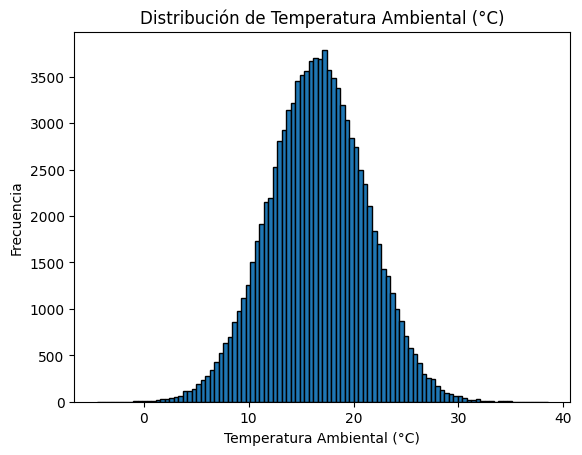

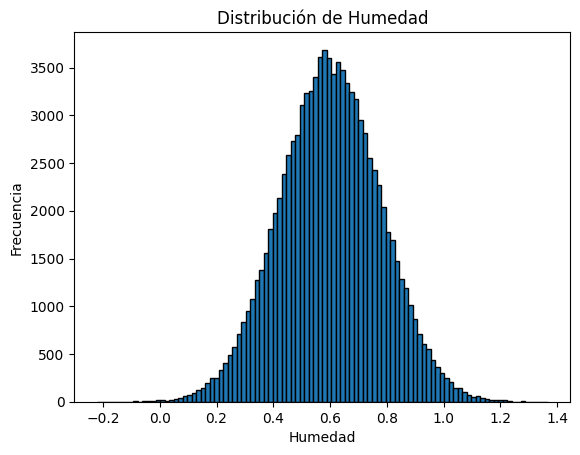

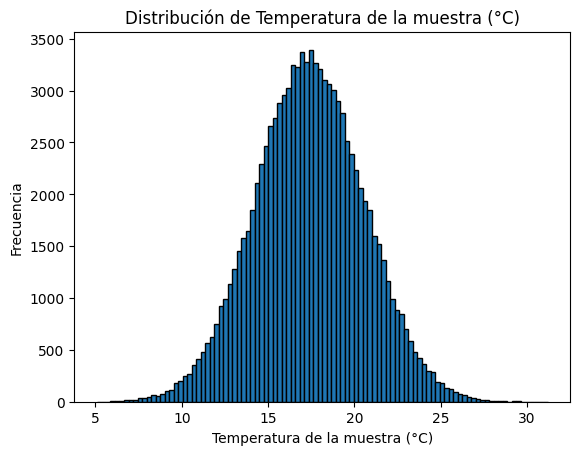

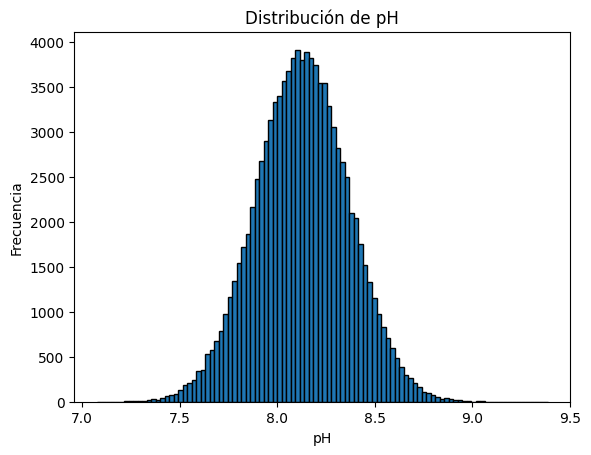

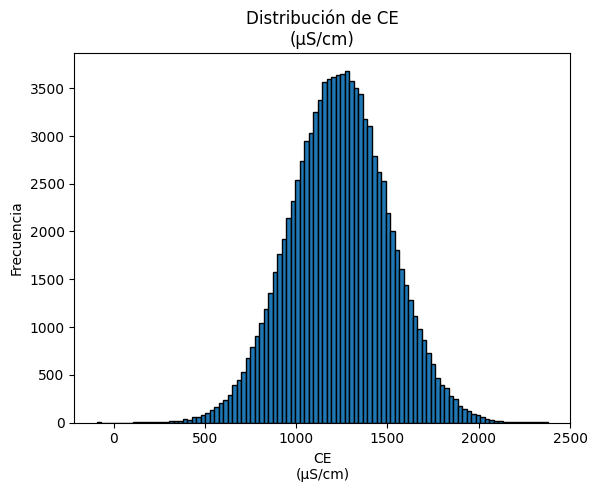

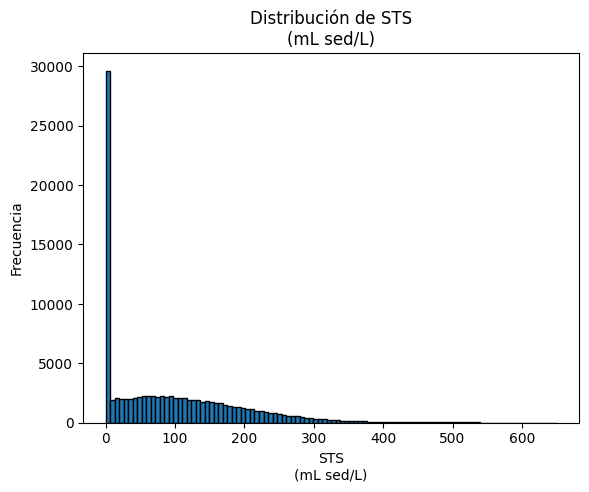

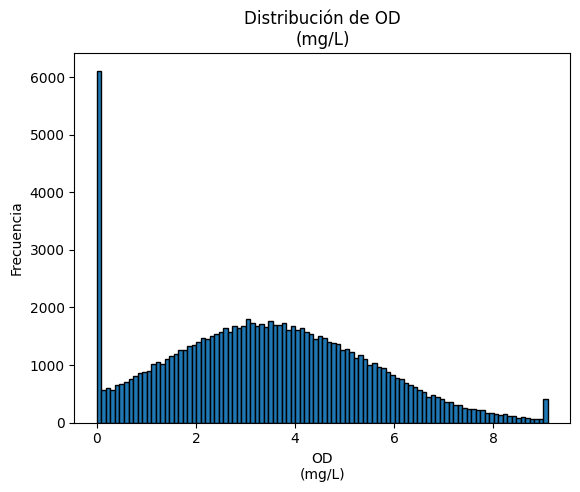

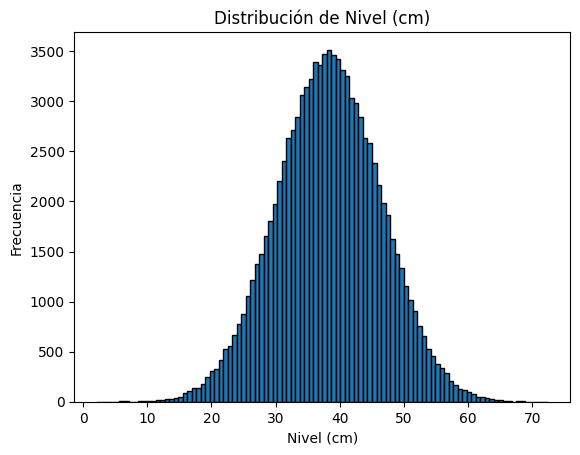

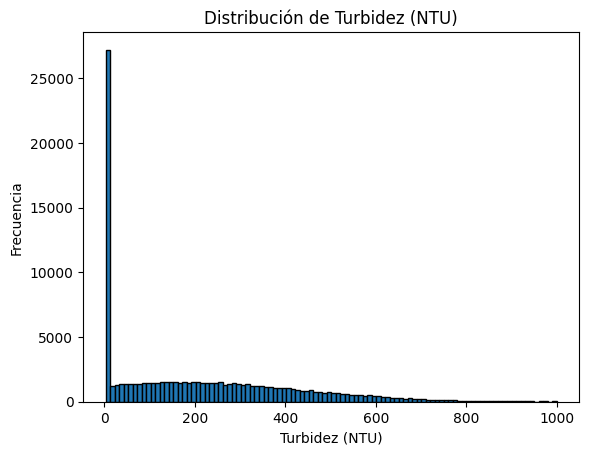

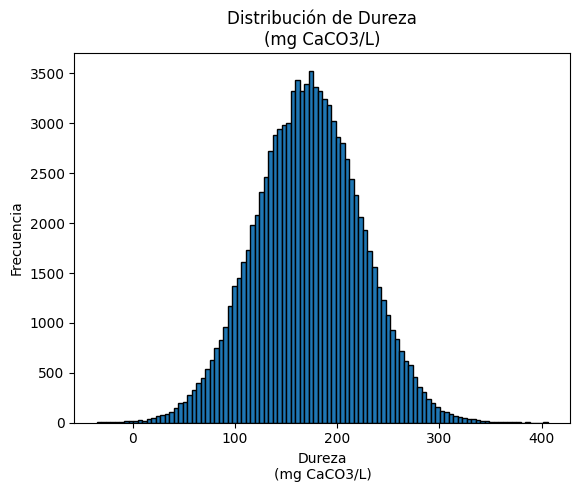

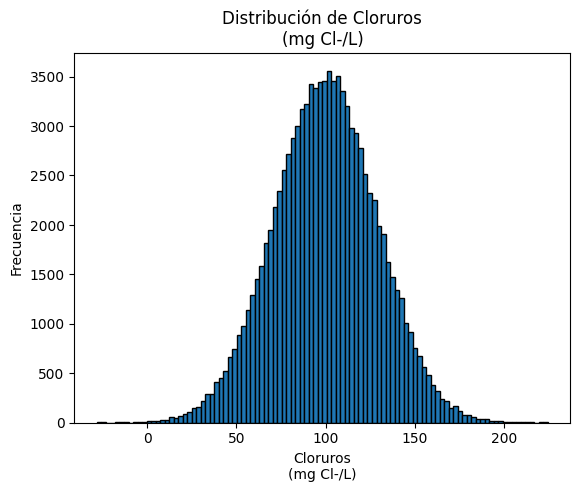

In [6]:
# PROCESO DE VISUALIZACIÓN DE DATOS #

import matplotlib.pyplot as plt

# Suponiendo que df_simulado es tu DataFrame con los datos simulados
for columna in df_simulado.columns:
    plt.figure()
    plt.hist(df_simulado[columna], bins=100, edgecolor='black')
    plt.title(f'Distribución de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.show()
